<a href="https://colab.research.google.com/github/Sumit05-Y/EDA-DATASCIENCE/blob/main/MallCustomerSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage


url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/Mall_Customers.csv"
df = pd.read_csv(url)
df["AnnualIncome_k"] = df["AnnualIncome"] / 1000

print(df.shape)
df.head()

(200, 6)


,CustomerID,Gender,Age,AnnualIncome,SpendingScore,AnnualIncome_k
0,1,Male,19,15000,39,15.0
1,2,Male,21,15000,81,15.0
2,3,Female,20,16000,6,16.0
3,4,Female,23,16000,77,16.0
4,5,Female,31,17000,40,17.0


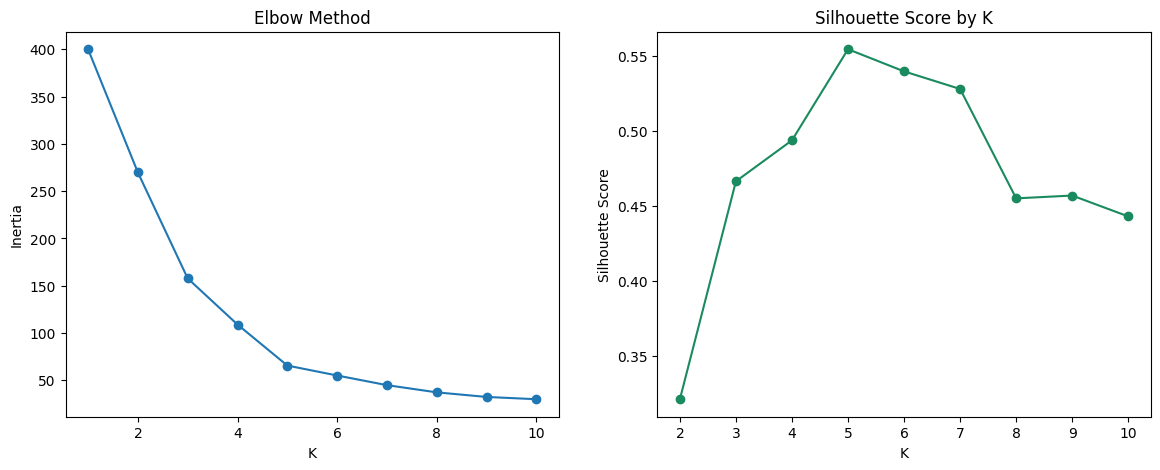

In [7]:
X = df[['AnnualIncome_k', 'SpendingScore']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias, silhouettes = [], []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    if k > 1:
        silhouettes.append(silhouette_score(X_scaled, labels))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, 11), inertias, marker='o')
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow Method")
axes[1].plot(range(2, 11), silhouettes, marker='o', color='#1A8A5F')
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score"); axes[1].set_title("Silhouette Score by K")
plt.show()



        AnnualIncome_k       SpendingScore      
                  mean count          mean count
Cluster                                         
0            55.296296    81     49.518519    81
1            86.538462    39     82.128205    39
2            25.727273    22     79.363636    22
3            88.200000    35     17.114286    35
4            26.304348    23     20.913043    23


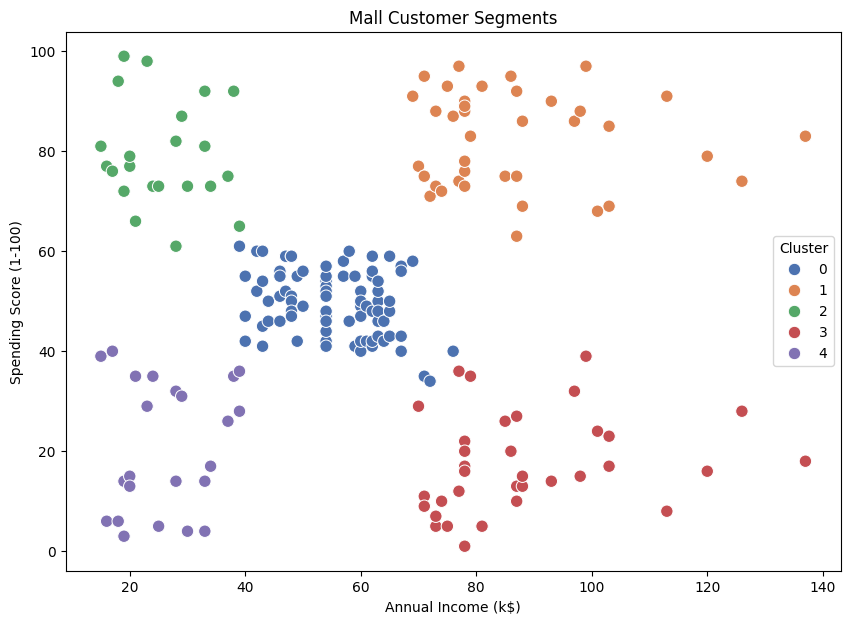

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
summary = df.groupby('Cluster')[["AnnualIncome_k","SpendingScore"]].agg(["mean","count"])
print(summary)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='AnnualIncome_k', y='SpendingScore', hue='Cluster', palette='deep', s=80)
plt.xlabel("Annual Income (k$)"); plt.ylabel("Spending Score (1-100)")
plt.title("Mall Customer Segments")
plt.show()


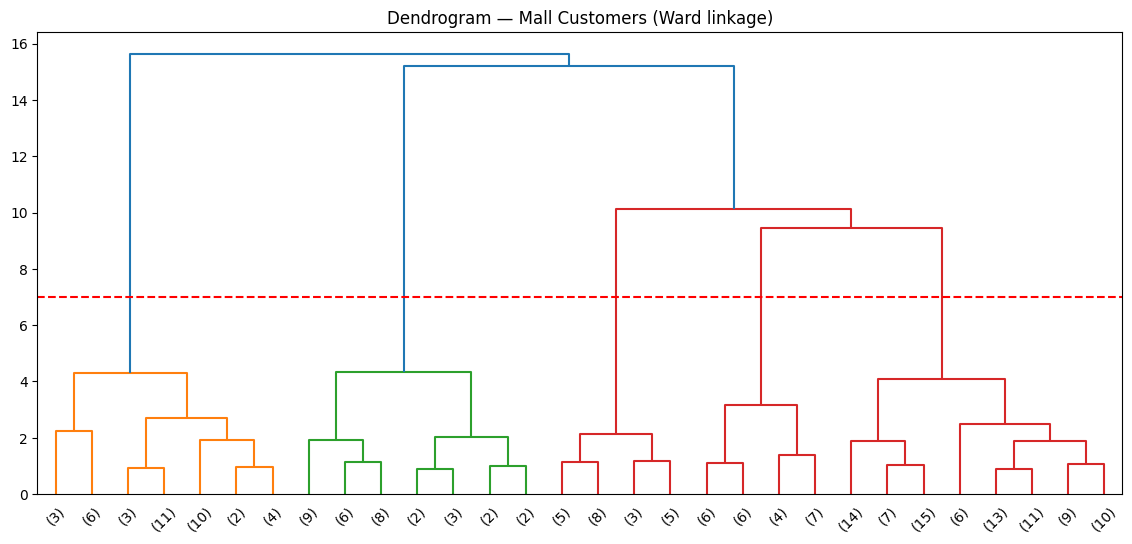

In [14]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.axhline(y=7, color='r', linestyle='--', label='Cut at 5 clusters')
plt.title("Dendrogram — Mall Customers (Ward linkage)")
plt.show()

from scipy.cluster.hierarchy import fcluster
hier_labels = fcluster(Z, t=5, criterion='maxclust')


Clusters: 4   Noise: 15 (7.5%)


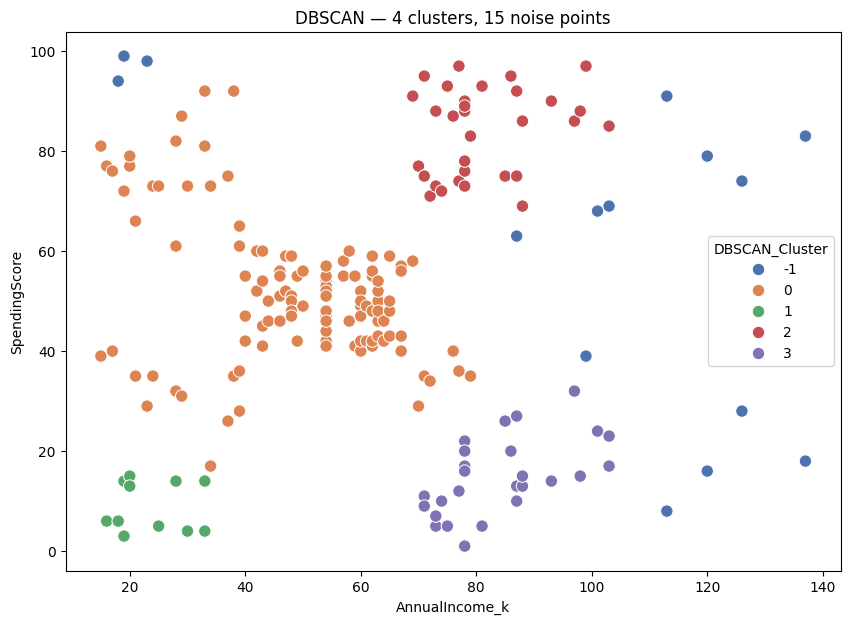

In [15]:
dbscan = DBSCAN(eps=0.4, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise = (df['DBSCAN_Cluster'] == -1).sum()
print(f"Clusters: {n_clusters}   Noise: {n_noise} ({n_noise/len(df)*100:.1f}%)")

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='AnnualIncome_k', y='SpendingScore', hue='DBSCAN_Cluster', palette='deep', s=80)
plt.title(f"DBSCAN — {n_clusters} clusters, {n_noise} noise points")
plt.show()


[0.44266167 0.33308378]
Total: 0.776


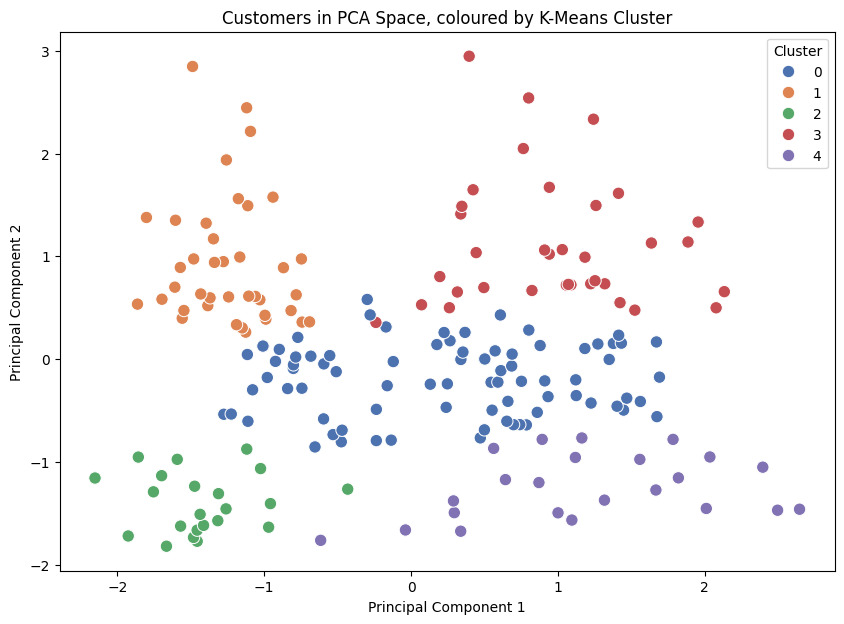

In [16]:
X3 = df[['Age', 'AnnualIncome_k', 'SpendingScore']].values
X3_scaled = StandardScaler().fit_transform(X3)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X3_scaled)
print(pca.explained_variance_ratio_)
print(f"Total: {pca.explained_variance_ratio_.sum():.3f}")

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['Cluster'], palette='deep', s=80)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customers in PCA Space, coloured by K-Means Cluster")
plt.show()

